In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib

In [2]:
!pip install --upgrade scikit-learn

In [3]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
data = pd.read_csv("university_student_stress_dataset.csv")
y = data["Stress_Level"]

features = ["Screen_Time", "Family_Support", "Assignment_Load", "Exam_Frequency", "Anxiety_Level", "Social_Media_Use", "Sleep_Hours"]
X = data[features].copy()

print(X.isnull().sum())
#No null values so no need to fill missing values
print(X.head())

Screen_Time         0
Family_Support      0
Assignment_Load     0
Exam_Frequency      0
Anxiety_Level       0
Social_Media_Use    0
Sleep_Hours         0
dtype: int64
   Screen_Time  Family_Support  Assignment_Load  Exam_Frequency  \
0            9               3                4               7   
1            8               7                8               6   
2            9               5                6               3   
3            6               6                6               8   
4            7               6                1               5   

   Anxiety_Level  Social_Media_Use  Sleep_Hours  
0              5                 6            6  
1              8                 6            5  
2              3                 7            5  
3              5                 5            8  
4              2                 0            6  


In [5]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)



NameError: name 'X_train' is not defined

Average Accuracy:  0.8540
Average Precision: 0.8801
Average Recall:    0.7729
Average F1 Macro:  0.8070
Average ROC-AUC:   0.9610


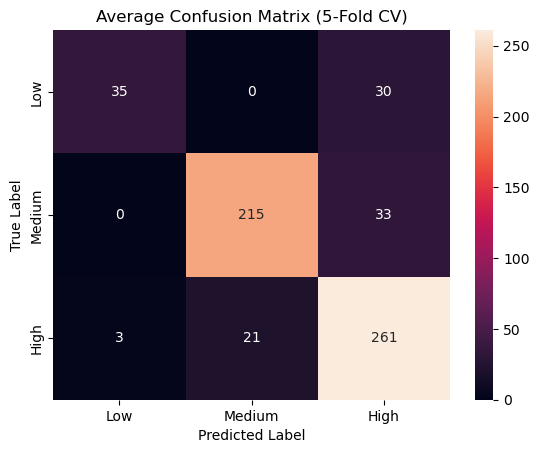

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix
import numpy as np

accuracies, precisions, recalls, f1s, roc_aucs = [], [], [], [], []
conf_matrices = []

for train, test in skf.split(X, y):
    X_train, X_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]

    model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average="macro"))
    recalls.append(recall_score(y_test, y_pred, average="macro"))
    f1s.append(f1_score(y_test, y_pred, average="macro"))
    roc_aucs.append(roc_auc_score(y_test, y_pred_proba, multi_class="ovr"))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

print(f"Average Accuracy:  {np.mean(accuracies):.4f}")
print(f"Average Precision: {np.mean(precisions):.4f}")
print(f"Average Recall:    {np.mean(recalls):.4f}")
print(f"Average F1 Macro:  {np.mean(f1s):.4f}")
print(f"Average ROC-AUC:   {np.mean(roc_aucs):.4f}")

# Average confusion matrix across folds
avg_conf = np.mean(conf_matrices, axis=0).astype(int)
sb.heatmap(avg_conf, annot=True, fmt="d", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.title("Average Confusion Matrix (5-Fold CV)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [7]:
final_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
    # add best params from GridSearch here if you ran it
)

final_model.fit(X, y)

import joblib

joblib.dump(final_model, "model.pkl")

print("model.pkl saved successfully")

model.pkl saved successfully


In [8]:
sample = X.iloc[[0]] 
final_model.predict(sample)

array(['Medium'], dtype=object)